# Neurodesign-plus progressive design tutorial

This tutorial walks through `neurodesign-plus` by starting from a minimal event-related experiment and adding one design element at a time. The examples use a generic decision-making task so that the design logic remains reusable across domains.

By the end, you will know how to:

1. define a simple experiment with one event and one condition,
2. add conditions while keeping the same trial structure,
3. separate conceptual trials from modeled events,
4. handle variable durations and transition-specific ITIs,
5. encode branching trial paths with sequence probabilities.

Each case has the same rhythm:

- The first code cell constructs a concrete timing example and shows the schedule.
- The second code cell defines the `Experiment` specification and `Design`, with illustrations of predicted BOLD signal.

In [1]:
import os

# Limit threads ? neurodesign uses multi-threading internally
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from collections import Counter
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from neurodesign import Experiment, Design, Optimisation, generate

GLOBAL_SEED = 11


---

## 1 — Helper functions used throughout the tutorial

The goal of the case-specific code cells is to show typical `Experiment` and `Design` usage as directly as possible. The helper functions below are only for visualization and for constructing explicit example schedules when that helps clarify timing.

In [2]:
def sample_scalar(spec, rng):
    if isinstance(spec, (int, float, np.integer, np.floating)):
        return float(spec)
    if not isinstance(spec, dict):
        raise TypeError(f"Unsupported specification type: {type(spec)}")

    model = spec["model"]
    if model == "fixed":
        return float(spec["value"])
    if model == "uniform":
        return float(rng.uniform(spec["min"], spec["max"]))
    if model == "gaussian":
        mean = spec["mean"]
        std = spec["std"]
        lo = spec.get("min", -np.inf)
        hi = spec.get("max", np.inf)
        for _ in range(1000):
            x = rng.normal(mean, std)
            if lo <= x <= hi:
                return float(x)
        return float(np.clip(mean, lo, hi))
    if model == "exponential":
        mean = spec["mean"]
        lo = spec.get("min", 0.0)
        hi = spec.get("max", np.inf)
        for _ in range(1000):
            x = rng.exponential(mean)
            if lo <= x <= hi:
                return float(x)
        return float(np.clip(mean, lo, hi))

    raise ValueError(f"Unknown model: {model}")


def resolve_duration(code, event_durations, rng):
    if isinstance(event_durations, (int, float, np.integer, np.floating, dict)):
        return sample_scalar(event_durations, rng)
    return sample_scalar(event_durations[code], rng)


def generate_gap_before(order, event_transition_rules, rng):
    gap_before = []
    for i, code in enumerate(order):
        prev_code = order[i - 1] if i > 0 else None
        key = (prev_code, code) if prev_code is not None else "default"
        params = event_transition_rules.get(key, event_transition_rules.get("default"))
        if params is None:
            raise KeyError(f"No ITI rule found for {key} and no default rule was provided.")
        gap_before.append(sample_scalar(params, rng))
    return gap_before


def tlist_to_order(trial_list, keys):
    order = []
    for entry in trial_list:
        order.extend(keys[entry])
    return order


def trial_list_to_ids(trial_list, keys):
    trial_ids = []
    for trial_id, entry in enumerate(trial_list):
        trial_ids.extend([trial_id] * len(keys[entry]))
    return trial_ids


def simulate_schedule(order, labels, event_durations, event_transition_rules, trial_start_interval=0.0, post_event_interval=0.0, trial_ids=None, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)

    if trial_ids is None:
        trial_ids = list(range(len(order)))

    gap_before = generate_gap_before(order, event_transition_rules, rng)

    rows = []
    cursor = 0.0
    prev_trial_id = None

    for i, code in enumerate(order):
        gap_start = cursor
        gap_end = cursor + gap_before[i]
        cursor = gap_end

        duration = resolve_duration(code, event_durations, rng)
        trial_start = cursor
        onset = trial_start + trial_start_interval
        offset = onset + duration
        trial_end = offset + post_event_interval

        if i == 0:
            gap_type = "initial gap"
        elif trial_ids[i] == prev_trial_id:
            gap_type = "within-trial gap"
        else:
            gap_type = "between-trial gap"

        rows.append({
            "event_index": i,
            "trial_id": trial_ids[i],
            "code": code,
            "label": labels[code],
            "gap_type": gap_type,
            "gap_before": gap_before[i],
            "gap_start": gap_start,
            "gap_end": gap_end,
            "trial_start": trial_start,
            "onset": onset,
            "duration": duration,
            "offset": offset,
            "trial_end": trial_end,
            "trial_start_interval": float(trial_start_interval),
            "post_event_interval": float(post_event_interval),
        })

        cursor = trial_end
        prev_trial_id = trial_ids[i]

    trial_bounds = []
    seen_trial_ids = []
    for row in rows:
        if row["trial_id"] not in seen_trial_ids:
            seen_trial_ids.append(row["trial_id"])
    for trial_id in seen_trial_ids:
        trial_rows = [row for row in rows if row["trial_id"] == trial_id]
        trial_bounds.append({
            "trial_id": trial_id,
            "trial_bar_start": min(row["trial_start"] for row in trial_rows),
            "trial_bar_end": max(row["trial_end"] for row in trial_rows),
            "first_event": min(row["event_index"] for row in trial_rows),
            "last_event": max(row["event_index"] for row in trial_rows),
        })

    return rows, trial_bounds


def plot_concise_timeline(schedule, trial_bounds, title, max_events=10):
    schedule = schedule[:max_events]
    shown_trials = {row["trial_id"] for row in schedule}
    trial_bounds = [row for row in trial_bounds if row["trial_id"] in shown_trials]

    xmax = max(max(row["trial_end"] for row in schedule), max(row["gap_end"] for row in schedule)) + 0.5
    fig, ax = plt.subplots(figsize=(14, 4.8))

    codes = sorted({row["code"] for row in schedule})
    cmap = plt.get_cmap("tab10", max(len(codes), 3))
    color_map = {code: cmap(i) for i, code in enumerate(codes)}

    gap_styles = {
        "initial gap": {"facecolor": "#ececec", "edgecolor": "#c7c7c7", "label": "initial gap"},
        "within-trial gap": {"facecolor": "#d9d9d9", "edgecolor": "#a6a6a6", "label": "within-trial gap"},
        "between-trial gap": {"facecolor": "#f2f2f2", "edgecolor": "#bdbdbd", "label": "between-trial gap"},
    }

    for row in trial_bounds:
        ax.add_patch(Rectangle((row["trial_bar_start"], 0.90), row["trial_bar_end"] - row["trial_bar_start"], 0.08, facecolor="0.95", edgecolor="0.35", linewidth=1.0))
        ax.text((row["trial_bar_start"] + row["trial_bar_end"]) / 2, 0.94, f"trial {int(row['trial_id']) + 1}", ha="center", va="center", fontsize=8)
        ax.vlines([row["trial_bar_start"], row["trial_bar_end"]], 0.82, 1.00, colors="0.35", linestyles="dashed", linewidth=0.9)
        ax.text(row["trial_bar_start"], 1.0, "trial start", ha="left", va="bottom", fontsize=7, color="0.25")
        ax.text(row["trial_bar_end"], 1.0, "trial end", ha="right", va="bottom", fontsize=7, color="0.25")

    for row in schedule:
        if row["gap_before"] > 0:
            style = gap_styles[row["gap_type"]]
            ax.add_patch(Rectangle((row["gap_start"], 0.18), row["gap_before"], 0.52, facecolor=style["facecolor"], edgecolor=style["edgecolor"]))
            label_y = 0.43 if row["gap_type"] != "within-trial gap" else 0.27
            ax.text((row["gap_start"] + row["gap_end"]) / 2, label_y, style["label"], ha="center", va="center", fontsize=7, color="0.25")

        if row["trial_start_interval"] > 0:
            ax.add_patch(Rectangle((row["trial_start"], 0.18), row["trial_start_interval"], 0.52, facecolor="#bdbdbd", edgecolor="#8c8c8c"))
            ax.text(row["trial_start"] + row["trial_start_interval"] / 2, 0.61, "trial_start_interval", ha="center", va="center", fontsize=8, color="0.15")

        ax.add_patch(Rectangle((row["onset"], 0.18), row["duration"], 0.52, facecolor=color_map[row["code"]], edgecolor="black", alpha=0.9))
        ax.text(row["onset"] + row["duration"] / 2, 0.44, row["label"], ha="center", va="center", fontsize=8)

        if row["post_event_interval"] > 0:
            ax.add_patch(Rectangle((row["offset"], 0.18), row["post_event_interval"], 0.52, facecolor="#969696", edgecolor="#737373"))
            ax.text(row["offset"] + row["post_event_interval"] / 2, 0.61, "post_event_interval", ha="center", va="center", fontsize=8, color="0.10")

        ax.vlines(row["onset"], 0.10, 0.75, colors="0.2", linestyles="dotted", linewidth=0.8)
        ax.text(row["onset"], 0.08, "onset", ha="center", va="top", fontsize=7, color="0.25")

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, 1.06)
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title(title)
    plt.tight_layout()
    return fig


def show_case_setup(title, order, labels, event_durations, event_transition_rules, trial_start_interval=0.0, post_event_interval=0.0, trial_ids=None, max_events=10, seed=GLOBAL_SEED):
    schedule, trial_bounds = simulate_schedule(
        order=order,
        labels=labels,
        event_durations=event_durations,
        event_transition_rules=event_transition_rules,
        trial_start_interval=trial_start_interval,
        post_event_interval=post_event_interval,
        trial_ids=trial_ids,
        seed=seed,
    )

    preview = [
        {
            "trial_id": row["trial_id"],
            "event_index": row["event_index"],
            "label": row["label"],
            "gap_type": row["gap_type"],
            "gap_before": round(row["gap_before"], 3),
            "trial_start": round(row["trial_start"], 3),
            "onset": round(row["onset"], 3),
            "offset": round(row["offset"], 3),
            "trial_end": round(row["trial_end"], 3),
        }
        for row in schedule[:max_events]
    ]
    pprint(preview)

    fig = plot_concise_timeline(schedule, trial_bounds, title=title, max_events=max_events)
    plt.show()
    plt.close(fig)

    return schedule, trial_bounds


def show_design_outputs(design, title, condition_labels):
    labels_in_order = [condition_labels[k] for k in sorted(condition_labels.keys())]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

    im = axes[0].imshow(design.Xconv, aspect="auto", cmap="viridis")
    axes[0].set_title(f"{title}: Convolved design matrix")
    axes[0].set_xlabel("Condition")
    axes[0].set_ylabel("Timepoints (TRs)")
    axes[0].set_xticks(range(len(labels_in_order)))
    axes[0].set_xticklabels(labels_in_order, rotation=45, ha="right")
    plt.colorbar(im, ax=axes[0], label="Predicted response")

    for idx, label in enumerate(labels_in_order):
        axes[1].plot(design.Xconv[:, idx], label=label)
    axes[1].set_title(f"{title}: Predicted BOLD")
    axes[1].set_xlabel("Timepoints (TRs)")
    axes[1].set_ylabel("Predicted BOLD (a.u.)")
    axes[1].legend(title="Event", loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


---

## 2 — Key concepts and objects

`neurodesign-plus` still revolves around the same core distinction as `neurodesign`:

| Object | Role |
|---|---|
| `Experiment` | Defines what stays fixed across candidate designs: TR, number of stimuli, contrasts, durations, and ITI model. |
| `Design` | Instantiates one concrete sequence: an order, an ITI list, and the resulting convolved design matrix. |
| `Optimisation` | Searches over many candidate designs. |

Four rules to remind throughout this tutorial.

1. `order` is event-level. It does not store conceptual trials. If one conceptual trial contains two modeled events, that trial contributes two entries to `order`.
2. `n_trials` refers to the number of modeled events in the `order`, not necessarily the number of conceptual trials in your task. As soon as one conceptual trial contains multiple modeled events, these two counts diverge.
3. `event_transition_interval` controls the gap before each event as a function of the previous and current event codes. In complex designs, that gap may correspond either to a within-trial fixation or to a between-trial ITI.
4. `trial_start_interval` and `post_event_interval` are event-level padding terms. If a fixation period belongs before every modeled event, `trial_start_interval` is a natural place to put it. If a gap depends on which event came before or after, it is usually clearer to represent that gap through the ITI list.

The timing figure used below makes this explicit. The top bar marks the conceptual trial. Gray segments mark gaps. The darker gray segment labeled `trial_start_interval` is the interval folded into the event definition through the `Experiment` object.

---

### A note on timing precision

The helper used in this notebook is explicit about what is being shown.

- `trial_start` is the start of the conceptual trial bar.
- `onset` is the modeled event onset.
- `trial_start_interval` is drawn inside the conceptual trial, before the modeled event.
- The gap before an event is classified either as a within-trial gap or as a between-trial ITI according to the `trial_id`.
- `trial_end` is the end of the conceptual trial bar.

This matters most once a conceptual trial contains more than one modeled event. In that situation, the same `event_transition_interval` mechanism can encode either a fixation within the trial or the ITI between trials. The distinction comes from the event-to-trial mapping, not from the ITI dictionary alone.

---

## 1 — One fixation, one event, one condition

The participant sees a fixation cross and then a single offer screen. The fixation is not a regressor of interest, so it is folded into `trial_start_interval`. This is the simplest case in which one conceptual trial corresponds to one event in `order`.

**Key parameters explained:**

- `n_stimuli = 1` because there is only one modeled event class.
- `n_trials = len(order)` because each conceptual trial contributes exactly one event.
- `P = [1.0]` because there is no condition variability.
- `C = [[1]]` because the only estimable regressor is the offer event itself.
- `trial_start_interval = 1.5` seconds because the fixation is represented as time before the event onset, not as a separate event.
- `inter_trial_interval="fixed"` and `inter_trial_interval["mean"]=0.0` because the only pre-event interval in this example is `trial_start_interval`.
- `event_transition_rules` must contain a default value. `(0, 0)` contains the ITI separating the first event (offer screen) from the next iteration of the first event (offer screen at next trial)

[{'event_index': 0,
  'gap_before': 0.0,
  'gap_type': 'initial gap',
  'label': 'offer',
  'offset': 2.7,
  'onset': 1.5,
  'trial_end': 2.7,
  'trial_id': 0,
  'trial_start': 0.0},
 {'event_index': 1,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer',
  'offset': 5.4,
  'onset': 4.2,
  'trial_end': 5.4,
  'trial_id': 1,
  'trial_start': 2.7},
 {'event_index': 2,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer',
  'offset': 8.1,
  'onset': 6.9,
  'trial_end': 8.1,
  'trial_id': 2,
  'trial_start': 5.4},
 {'event_index': 3,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer',
  'offset': 10.8,
  'onset': 9.6,
  'trial_end': 10.8,
  'trial_id': 3,
  'trial_start': 8.1},
 {'event_index': 4,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer',
  'offset': 13.5,
  'onset': 12.3,
  'trial_end': 13.5,
  'trial_id': 4,
  'trial_start': 10.8},
 {'event_index': 5,
  'gap_before': 0.0,
  'gap_type': 

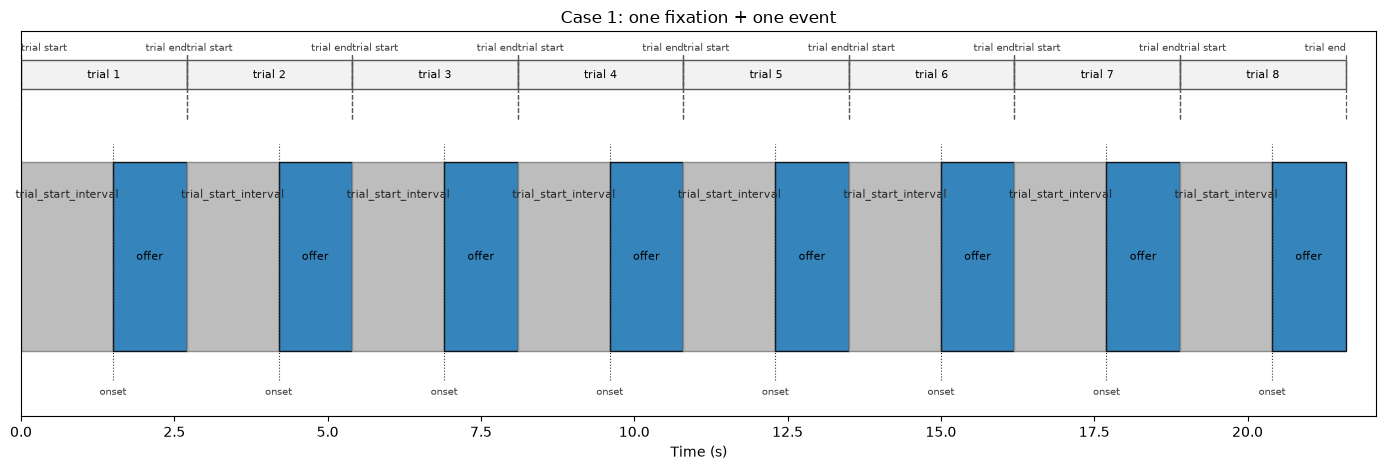

In [3]:
labels_1 = {0: "offer"}
order_1 = [0] * 12
trial_ids_1 = list(range(len(order_1)))
event_durations_1 = [1.2]
event_transition_rules_1 = {
    "default": {"model": "fixed", "value": 0.0},
    (0, 0): {"model": "fixed", "value": 0.0},
}

schedule_1, trial_bounds_1 = show_case_setup(
    title="Case 1: one fixation + one event",
    order=order_1,
    labels=labels_1,
    event_durations=event_durations_1,
    event_transition_rules=event_transition_rules_1,
    trial_start_interval=1.5,
    post_event_interval=0.0,
    trial_ids=trial_ids_1,
    max_events=8,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 38.5031
Fd (detection efficiency):  0.0705
Fc (collinearity):          0.0000
Ff (frequency balance):     1.0000


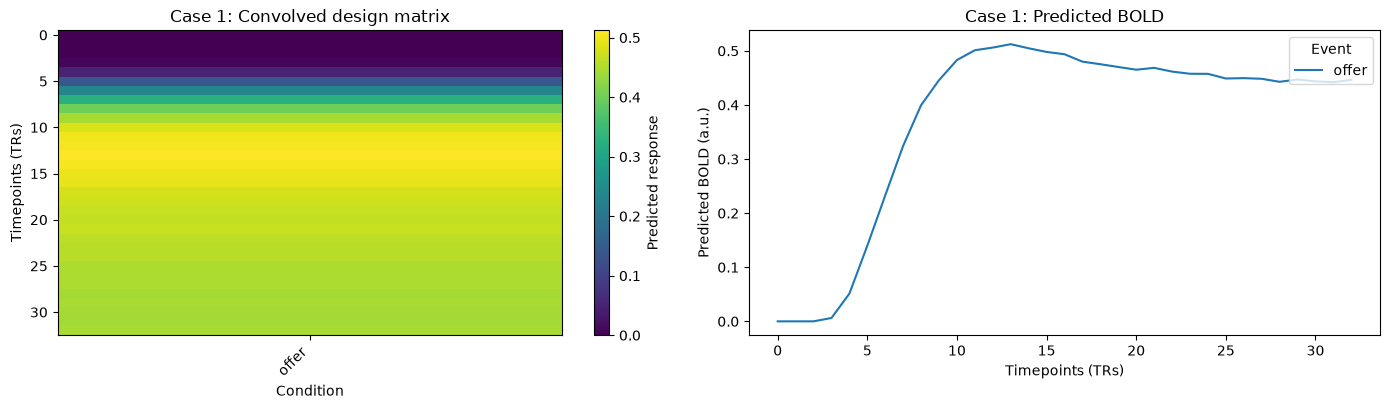

In [4]:
# Create the experiment
exp_1 = Experiment(
        TR=1.0,                    # Repetition time in seconds
        n_trials=len(order_1),     # One event per conceptual trial
        P=[1.0],                   # Only one condition
        C=np.array([[1]]),         # Contrast on the single event regressor
        n_stimuli=1,               # Number of modeled event classes
        rho=0.3,                   # AR(1) autocorrelation used in efficiency calculations
        event_durations=1.2,         # Base event duration argument
        trial_start_interval=1.5,                 # Fixation folded before the event
        post_event_interval=0.0,                # No post-event padding in this example
        inter_trial_interval={"model": "fixed", "value": 0.0},  #Global ITI model for the experiment container / Zero because all pre-event time is already in trial_start_interval
        order=order_1,
        
)

# Create one concrete design
design_1 = exp_1.create_manual_design(
    order=order_1,
    inter_trial_intervals=np.array([row["gap_before"] for row in schedule_1]),
)

# Build the convolved design matrix
design_1.designmatrix()

# Compute the standard efficiency metrics
design_1.FeCalc()
design_1.FdCalc()
design_1.FcCalc()
design_1.FfCalc()

print(f"Fe (estimation efficiency): {design_1.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_1.Fd:.4f}")
print(f"Fc (collinearity):          {design_1.Fc:.4f}")
print(f"Ff (frequency balance):     {design_1.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_1,
    title="Case 1",
    condition_labels=labels_1,
)


---

## 2 — Same structure, now with two conditions

The trial architecture is unchanged. The only difference is that the offer screen now has two conditions, here labeled `offer_small` and `offer_large`. This case isolates the distinction between changing trial structure and changing event coding.

**Key parameters explained:**

- `n_stimuli = 2` because the single event now has two condition labels.
- `P = [0.5, 0.5]` because the two offer types are balanced.
- `C` now includes the two main-effect regressors and a difference contrast.
- `trial_start_interval` stays the same because the fixation architecture has not changed.
- `n_trials` still equals the number of conceptual trials because each trial still contributes one event.
- `event_transition_rules` list contains the ITI for the transitions between offer_small and offer_large. They are all set to 0.

[{'event_index': 0,
  'gap_before': 0.0,
  'gap_type': 'initial gap',
  'label': 'offer_small',
  'offset': 2.7,
  'onset': 1.5,
  'trial_end': 2.7,
  'trial_id': 0,
  'trial_start': 0.0},
 {'event_index': 1,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_large',
  'offset': 5.4,
  'onset': 4.2,
  'trial_end': 5.4,
  'trial_id': 1,
  'trial_start': 2.7},
 {'event_index': 2,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_small',
  'offset': 8.1,
  'onset': 6.9,
  'trial_end': 8.1,
  'trial_id': 2,
  'trial_start': 5.4},
 {'event_index': 3,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_large',
  'offset': 10.8,
  'onset': 9.6,
  'trial_end': 10.8,
  'trial_id': 3,
  'trial_start': 8.1},
 {'event_index': 4,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_small',
  'offset': 13.5,
  'onset': 12.3,
  'trial_end': 13.5,
  'trial_id': 4,
  'trial_start': 10.8},
 {'event_index': 5,
  'ga

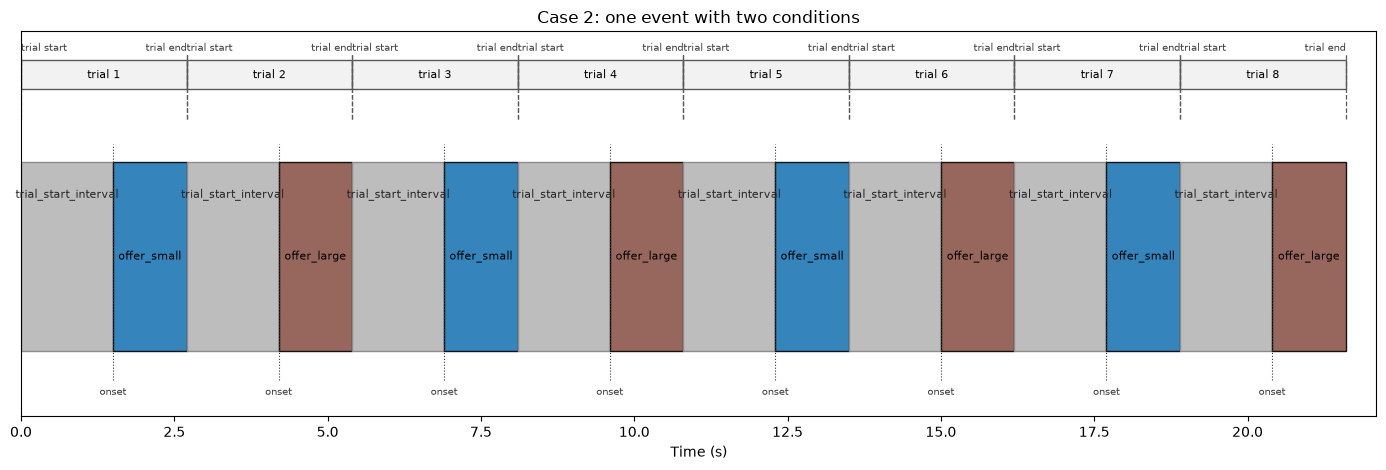

In [5]:
labels_2 = {
    0: "offer_small",
    1: "offer_large",
}
order_2 = [0, 1] * 6
trial_ids_2 = list(range(len(order_2)))
event_durations_2 = [1.2, 1.2]
event_transition_rules_2 = {
    "default": {"model": "fixed", "value": 0.0},
    (0, 0): {"model": "fixed", "value": 0.0},
    (0, 1): {"model": "fixed", "value": 0.0},
    (1, 0): {"model": "fixed", "value": 0.0},
    (1, 1): {"model": "fixed", "value": 0.0},
}

schedule_2, trial_bounds_2 = show_case_setup(
    title="Case 2: one event with two conditions",
    order=order_2,
    labels=labels_2,
    event_durations=event_durations_2,
    event_transition_rules=event_transition_rules_2,
    trial_start_interval=1.5,
    post_event_interval=0.0,
    trial_ids=trial_ids_2,
    max_events=8,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 62.5635
Fd (detection efficiency):  0.0337
Fc (collinearity):          0.3939
Ff (frequency balance):     1.0000


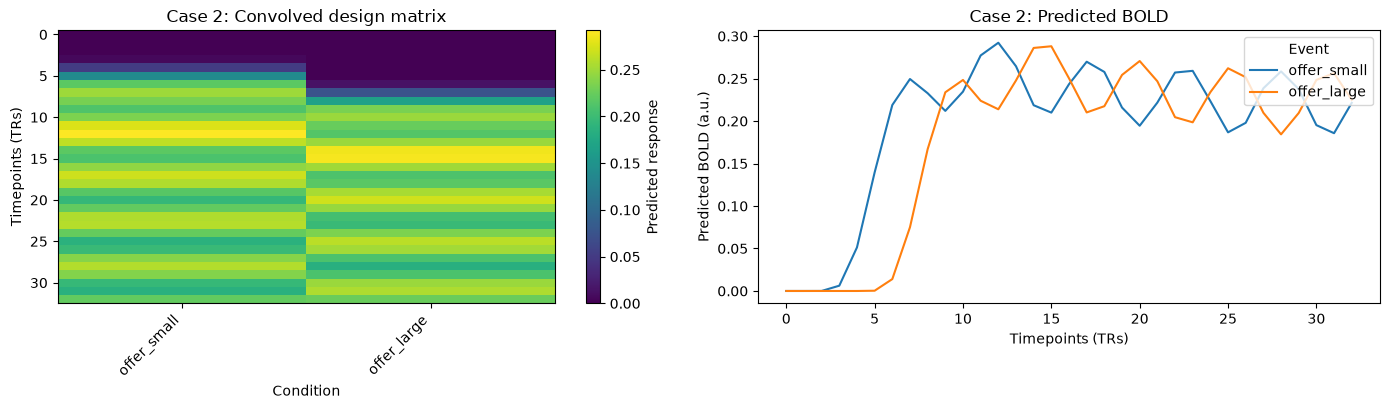

In [6]:
# Create the experiment
exp_2 = Experiment(
        TR=1.0,
        n_trials=len(order_2),
        P=[0.5, 0.5],
        C=np.array([
            [1, 0],    # offer_small
            [0, 1],    # offer_large
            [1, -1],   # offer_small > offer_large
        ]),
        n_stimuli=2,
        rho=0.3,
        event_durations=1.2,
        trial_start_interval=1.5,
        post_event_interval=0.0,
        inter_trial_interval={"model": "fixed", "value": 0.0},
        order=order_2,
        
)

# Create one concrete design
design_2 = exp_2.create_manual_design(
    order=order_2,
    inter_trial_intervals=np.array([row["gap_before"] for row in schedule_2]),
)

# Build the convolved design matrix
design_2.designmatrix()

# Compute the standard efficiency metrics
design_2.FeCalc()
design_2.FdCalc()
design_2.FcCalc()
design_2.FfCalc()

print(f"Fe (estimation efficiency): {design_2.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_2.Fd:.4f}")
print(f"Fc (collinearity):          {design_2.Fc:.4f}")
print(f"Ff (frequency balance):     {design_2.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_2,
    title="Case 2",
    condition_labels=labels_2,
)


---

## 3 — Same structure, now with three conditions

The trial is still fixation followed by a single event. The only new element is a third offer category. This is the last case in which one conceptual trial still maps cleanly onto one event entry.

**Key parameters explained:**

- `n_stimuli = 3` because the one event now has three condition labels.
- `P = [1/3, 1/3, 1/3]` when the categories are balanced.
- `C` can include both main-effect rows and selected pairwise contrasts.
- `event_durations` can still be a single scalar because all three offer types share the same duration here.

[{'event_index': 0,
  'gap_before': 0.0,
  'gap_type': 'initial gap',
  'label': 'offer_small',
  'offset': 2.7,
  'onset': 1.5,
  'trial_end': 2.7,
  'trial_id': 0,
  'trial_start': 0.0},
 {'event_index': 1,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_medium',
  'offset': 5.4,
  'onset': 4.2,
  'trial_end': 5.4,
  'trial_id': 1,
  'trial_start': 2.7},
 {'event_index': 2,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_large',
  'offset': 8.1,
  'onset': 6.9,
  'trial_end': 8.1,
  'trial_id': 2,
  'trial_start': 5.4},
 {'event_index': 3,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_small',
  'offset': 10.8,
  'onset': 9.6,
  'trial_end': 10.8,
  'trial_id': 3,
  'trial_start': 8.1},
 {'event_index': 4,
  'gap_before': 0.0,
  'gap_type': 'between-trial gap',
  'label': 'offer_medium',
  'offset': 13.5,
  'onset': 12.3,
  'trial_end': 13.5,
  'trial_id': 4,
  'trial_start': 10.8},
 {'event_index': 5,
  '

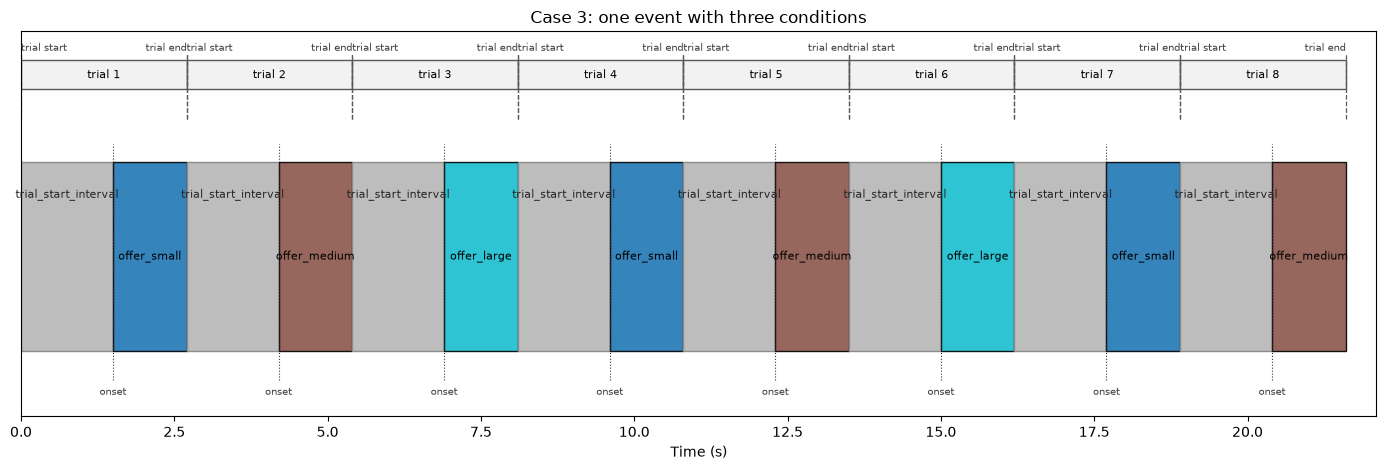

In [7]:
labels_3 = {
    0: "offer_small",
    1: "offer_medium",
    2: "offer_large",
}
order_3 = [0, 1, 2] * 4
trial_ids_3 = list(range(len(order_3)))
event_durations_3 = [1.2, 1.2, 1.2]
event_transition_rules_3 = {
    "default": {"model": "fixed", "value": 0.0},
    (0, 0): {"model": "fixed", "value": 0.0},
    (0, 1): {"model": "fixed", "value": 0.0},
    (0, 2): {"model": "fixed", "value": 0.0},
    (1, 0): {"model": "fixed", "value": 0.0},
    (1, 1): {"model": "fixed", "value": 0.0},
    (1, 2): {"model": "fixed", "value": 0.0},
    (2, 0): {"model": "fixed", "value": 0.0},
    (2, 1): {"model": "fixed", "value": 0.0},
    (2, 2): {"model": "fixed", "value": 0.0},
}

schedule_3, trial_bounds_3 = show_case_setup(
    title="Case 3: one event with three conditions",
    order=order_3,
    labels=labels_3,
    event_durations=event_durations_3,
    event_transition_rules=event_transition_rules_3,
    trial_start_interval=1.5,
    post_event_interval=0.0,
    trial_ids=trial_ids_3,
    max_events=8,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 63.3919
Fd (detection efficiency):  0.0498
Fc (collinearity):          0.2873
Ff (frequency balance):     1.0000


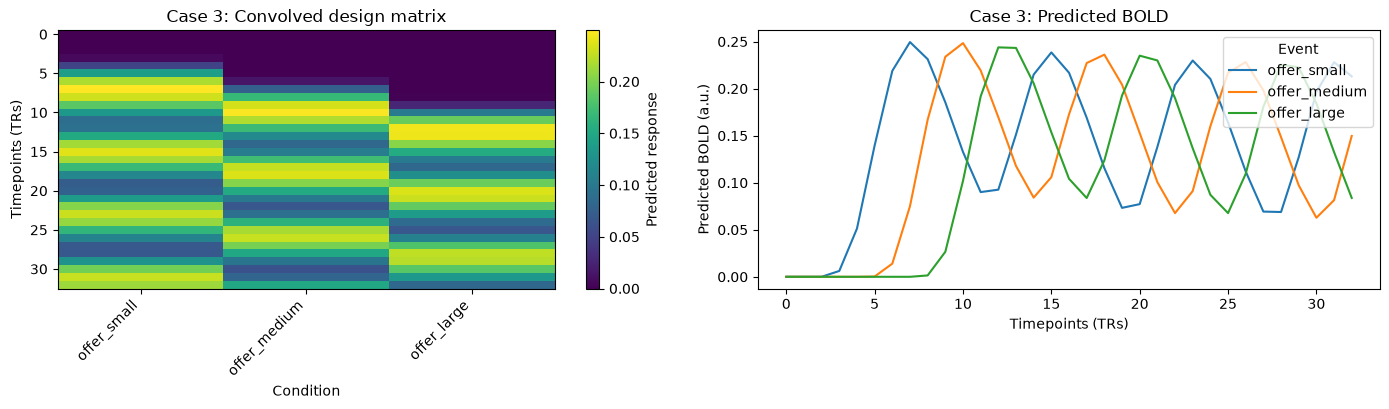

In [8]:
# Create the experiment
exp_3 = Experiment(
        TR=1.0,
        n_trials=len(order_3),
        P=[1/3, 1/3, 1/3],
        C=np.array([
            [1, 0, 0],    # offer_small
            [0, 1, 0],    # offer_medium
            [0, 0, 1],    # offer_large
            [1, 0, -1],   # offer_small > offer_large
        ]),
        n_stimuli=3,
        rho=0.3,
        event_durations=1.2,
        trial_start_interval=1.5,
        post_event_interval=0.0,
        inter_trial_interval={"model": "fixed", "value": 0.0},
        order=order_3,
        
)

# Create one concrete design
design_3 = exp_3.create_manual_design(
    order=order_3,
    inter_trial_intervals=np.array([row["gap_before"] for row in schedule_3]),
)

# Build the convolved design matrix
design_3.designmatrix()

# Compute the standard efficiency metrics
design_3.FeCalc()
design_3.FdCalc()
design_3.FcCalc()
design_3.FfCalc()

print(f"Fe (estimation efficiency): {design_3.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_3.Fd:.4f}")
print(f"Fc (collinearity):          {design_3.Fc:.4f}")
print(f"Ff (frequency balance):     {design_3.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_3,
    title="Case 3",
    condition_labels=labels_3,
)


---

## 4 — Two modeled events per conceptual trial

Each conceptual trial now contains a cue followed by a choice screen. This is the first case in which the conceptual trial and the event-level order diverge. The within-trial fixation between cue and choice is encoded through `event_transition_interval`, but the timing figure shows that it still falls inside the same conceptual trial bar.

**Key parameters explained:**

- `n_trials = len(order)` now counts event entries, not conceptual trials.
- `n_stimuli = 2` because there are two event classes: `cue` and `choice`.
- `event_durations = [0.8, 1.4]` because the two event classes have different fixed durations.
- `trial_max = 1.4` is required once event durations are provided through `event_durations`.
- `event_transition_interval` is needed because the gap before `choice` is not the same as the gap before the next cue.
- `inter_trial_interval["mean"]` is still given globally because the experiment container needs an expected ITI even when a conditional ITI dictionary is used.
- `event_transition_rules` contains a non-zero list. In this case, the ITI between cue and choice is `0.8`, and the ITI between choice and cue is set to `1.2`. Here, the `default` ITI will determine the *initial gap* only, as you can see on the task schedule below.

[{'event_index': 0,
  'gap_before': 0.6,
  'gap_type': 'initial gap',
  'label': 'cue',
  'offset': 1.4,
  'onset': 0.6,
  'trial_end': 1.4,
  'trial_id': 0,
  'trial_start': 0.6},
 {'event_index': 1,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice',
  'offset': 3.6,
  'onset': 2.2,
  'trial_end': 3.6,
  'trial_id': 0,
  'trial_start': 2.2},
 {'event_index': 2,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue',
  'offset': 5.6,
  'onset': 4.8,
  'trial_end': 5.6,
  'trial_id': 1,
  'trial_start': 4.8},
 {'event_index': 3,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice',
  'offset': 7.8,
  'onset': 6.4,
  'trial_end': 7.8,
  'trial_id': 1,
  'trial_start': 6.4},
 {'event_index': 4,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue',
  'offset': 9.8,
  'onset': 9.0,
  'trial_end': 9.8,
  'trial_id': 2,
  'trial_start': 9.0},
 {'event_index': 5,
  'gap_before': 0.8,
  'gap_type': 'within-tria

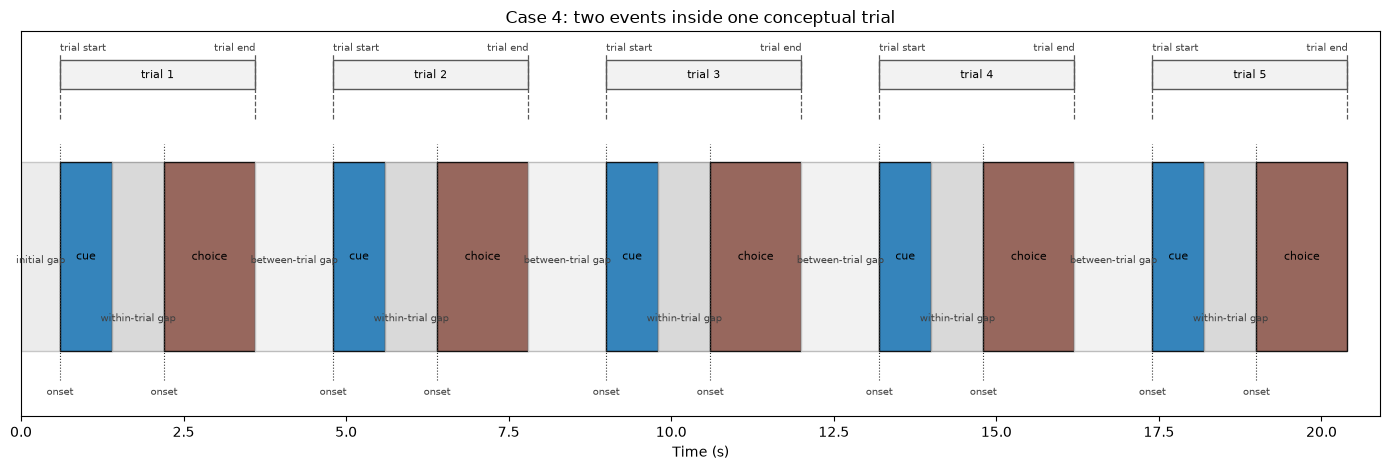

In [9]:
labels_4 = {
    0: "cue",
    1: "choice",
}
order_4 = [0, 1] * 8
trial_ids_4 = [i for i in range(8) for _ in (0, 1)]
event_durations_4 = [0.8, 1.4]
event_transition_rules_4 = {
    "default": {"model": "fixed", "value": 0.6},
    (0, 1): {"model": "fixed", "value": 0.8},   # within-trial fixation before choice
    (1, 0): {"model": "fixed", "value": 1.2},   # ITI before the next cue
}

schedule_4, trial_bounds_4 = show_case_setup(
    title="Case 4: two events inside one conceptual trial",
    order=order_4,
    labels=labels_4,
    event_durations=event_durations_4,
    event_transition_rules=event_transition_rules_4,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_4,
    max_events=10,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 320.0081
Fd (detection efficiency):  0.0297
Fc (collinearity):          0.3778
Ff (frequency balance):     1.0000


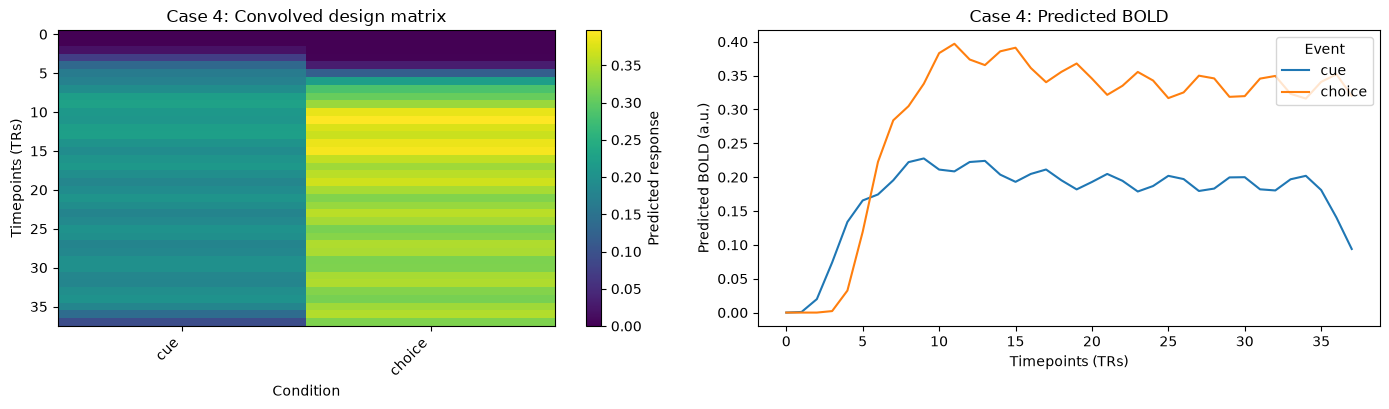

In [10]:
# Create the experiment
exp_4 = Experiment(
        TR=1.0,
        n_trials=len(order_4),          # Event-level count, not conceptual-trial count
        P=[0.5, 0.5],
        C=np.array([
            [1, 0],   # cue
            [0, 1],   # choice
        ]),
        n_stimuli=2,
        rho=0.3,
        event_durations=event_durations_4,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "fixed", "value": 1.0},
        event_transition_interval={"by_event_transition": event_transition_rules_4},
        order=order_4,
        
        trial_max=max(event_durations_4),
)

# Create one concrete design
design_4 = exp_4.create_design(seed=GLOBAL_SEED + 14)
# Build the convolved design matrix
design_4.designmatrix()

# Compute the standard efficiency metrics
design_4.FeCalc()
design_4.FdCalc()
design_4.FcCalc()
design_4.FfCalc()

print(f"Fe (estimation efficiency): {design_4.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_4.Fd:.4f}")
print(f"Fc (collinearity):          {design_4.Fc:.4f}")
print(f"Ff (frequency balance):     {design_4.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_4,
    title="Case 4",
    condition_labels=labels_4,
)


---

 ## 5 — The second event now has two conditions

Relative to Case 4, only one thing changes: the choice screen now has two forms, `choice_left` and `choice_right`. This is the first case where the correct event coding is not the same as the conceptual trial labels. The cue remains one event class, but the second event splits into two classes because the design matrix needs separate regressors for them.

**Key parameters explained:**

- `n_stimuli = 3` because the modeled event classes are now `cue`, `choice_left`, and `choice_right`.
- `P` changes because the event pool now has three classes rather than two.
- `C` can focus on the choice-phase contrast even though the cue is still part of the design matrix.
- `event_durations` must now have one entry per event code.
- `n_trials` remains event-level, so each conceptual trial still contributes two entries to `order`.
- `event_transition_rules` contains 4 ITI possibilities: `0.8` for the ITI between the cue and any choice, and `1.2` for the ITI between any choice and the cue.

[{'event_index': 0,
  'gap_before': 0.6,
  'gap_type': 'initial gap',
  'label': 'cue',
  'offset': 1.4,
  'onset': 0.6,
  'trial_end': 1.4,
  'trial_id': 0,
  'trial_start': 0.6},
 {'event_index': 1,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice_left',
  'offset': 3.6,
  'onset': 2.2,
  'trial_end': 3.6,
  'trial_id': 0,
  'trial_start': 2.2},
 {'event_index': 2,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue',
  'offset': 5.6,
  'onset': 4.8,
  'trial_end': 5.6,
  'trial_id': 1,
  'trial_start': 4.8},
 {'event_index': 3,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice_right',
  'offset': 7.8,
  'onset': 6.4,
  'trial_end': 7.8,
  'trial_id': 1,
  'trial_start': 6.4},
 {'event_index': 4,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue',
  'offset': 9.8,
  'onset': 9.0,
  'trial_end': 9.8,
  'trial_id': 2,
  'trial_start': 9.0},
 {'event_index': 5,
  'gap_before': 0.8,
  'gap_type': '

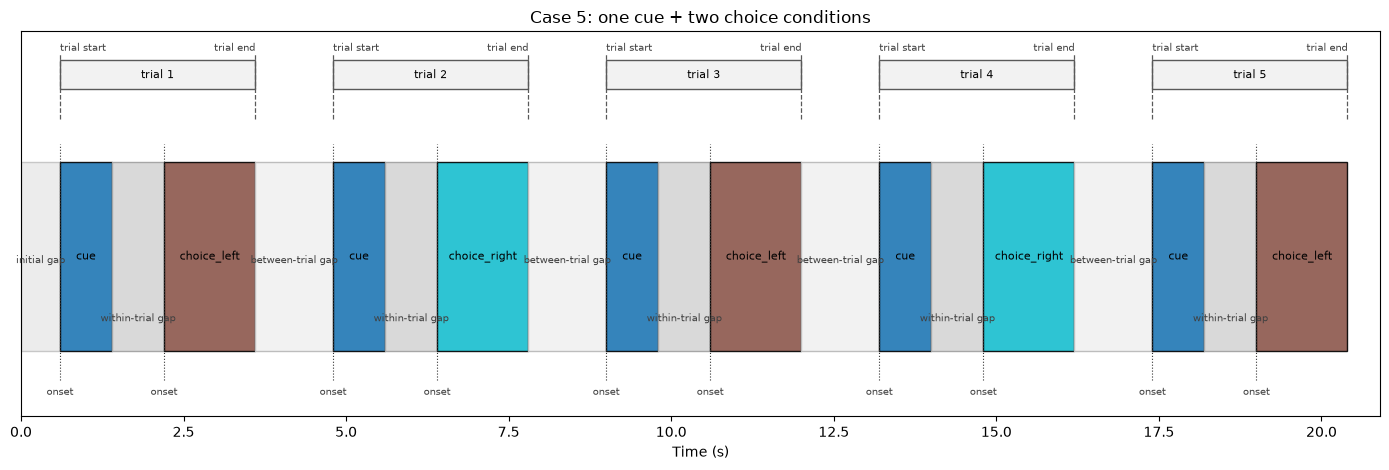

In [11]:
labels_5 = {
    0: "cue",
    1: "choice_left",
    2: "choice_right",
}
order_5 = [0, 1, 0, 2] * 4
trial_ids_5 = [i for i in range(8) for _ in (0, 1)]
event_durations_5 = [0.8, 1.4, 1.4]
event_transition_rules_5 = {
    "default": {"model": "fixed", "value": 0.6},
    (0, 1): {"model": "fixed", "value": 0.8},
    (0, 2): {"model": "fixed", "value": 0.8},
    (1, 0): {"model": "fixed", "value": 1.2},
    (2, 0): {"model": "fixed", "value": 1.2},
}

schedule_5, trial_bounds_5 = show_case_setup(
    title="Case 5: one cue + two choice conditions",
    order=order_5,
    labels=labels_5,
    event_durations=event_durations_5,
    event_transition_rules=event_transition_rules_5,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_5,
    max_events=10,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 628.0793
Fd (detection efficiency):  0.0601
Fc (collinearity):          0.4661
Ff (frequency balance):     1.0000


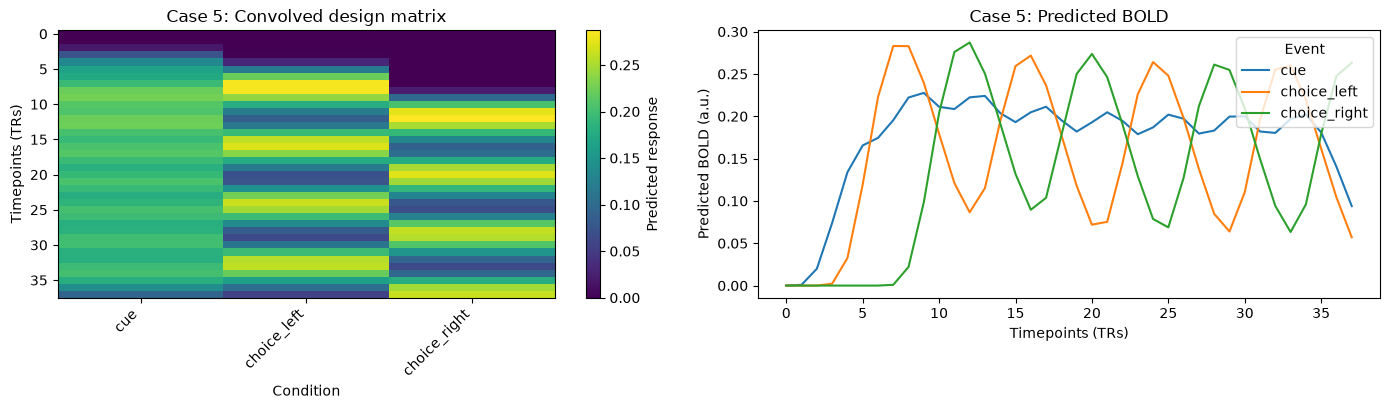

In [12]:
# Create the experiment
exp_5 = Experiment(
        TR=1.0,
        n_trials=len(order_5),
        P=[0.5, 0.25, 0.25],
        C=np.array([
            [0, 1, 0],   # choice_left
            [0, 0, 1],   # choice_right
            [0, 1, -1],  # choice_left > choice_right
        ]),
        n_stimuli=3,
        rho=0.3,
        event_durations=event_durations_5,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "fixed", "value": 1.0},
        event_transition_interval={"by_event_transition": event_transition_rules_5},
        order=order_5,
        
        trial_max=max(event_durations_5),
)

# Create one concrete design
design_5 = exp_5.create_design(seed=GLOBAL_SEED + 15)
# Build the convolved design matrix
design_5.designmatrix()

# Compute the standard efficiency metrics
design_5.FeCalc()
design_5.FdCalc()
design_5.FcCalc()
design_5.FfCalc()

print(f"Fe (estimation efficiency): {design_5.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_5.Fd:.4f}")
print(f"Fc (collinearity):          {design_5.Fc:.4f}")
print(f"Ff (frequency balance):     {design_5.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_5,
    title="Case 5",
    condition_labels=labels_5,
)


---

## 6 — Both events now have conditions

 Only one complexity is added relative to Case 5: the cue itself now has two conditions. Each conceptual trial still contains exactly two events, but both phases now contribute condition-specific regressors.

**Key parameters explained:**

- `n_stimuli = 4` because the modeled classes are `cue_easy`, `cue_hard`, `choice_left`, and `choice_right`.
- `P` now reflects the four event classes rather than the conceptual trial templates.
- `C` can test cue-phase and choice-phase contrasts independently.
- The event-level representation is a cross-product of phase and condition, not a single conceptual label per trial.

[{'event_index': 0,
  'gap_before': 0.6,
  'gap_type': 'initial gap',
  'label': 'cue_easy',
  'offset': 1.4,
  'onset': 0.6,
  'trial_end': 1.4,
  'trial_id': 0,
  'trial_start': 0.6},
 {'event_index': 1,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice_left',
  'offset': 3.6,
  'onset': 2.2,
  'trial_end': 3.6,
  'trial_id': 0,
  'trial_start': 2.2},
 {'event_index': 2,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue_easy',
  'offset': 5.6,
  'onset': 4.8,
  'trial_end': 5.6,
  'trial_id': 1,
  'trial_start': 4.8},
 {'event_index': 3,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice_right',
  'offset': 7.8,
  'onset': 6.4,
  'trial_end': 7.8,
  'trial_id': 1,
  'trial_start': 6.4},
 {'event_index': 4,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue_hard',
  'offset': 9.8,
  'onset': 9.0,
  'trial_end': 9.8,
  'trial_id': 2,
  'trial_start': 9.0},
 {'event_index': 5,
  'gap_before': 0.8,


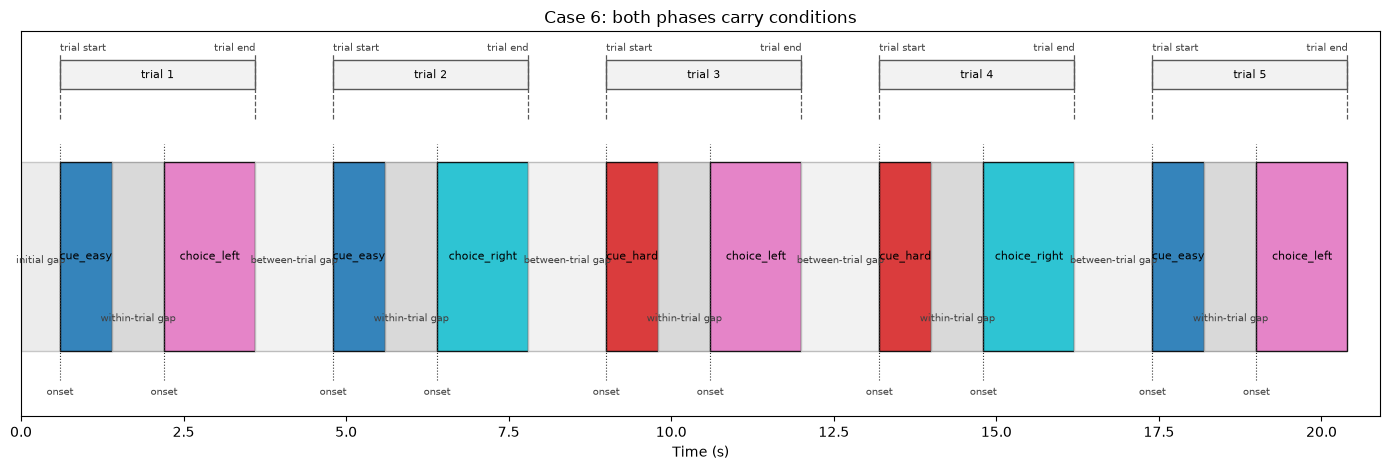

In [13]:
labels_6 = {
    0: "cue_easy",
    1: "cue_hard",
    2: "choice_left",
    3: "choice_right",
}
order_6 = [0, 2, 0, 3, 1, 2, 1, 3] * 2
trial_ids_6 = [i for i in range(8) for _ in (0, 1)]
event_durations_6 = [0.8, 0.8, 1.4, 1.4]
event_transition_rules_6 = {
    "default": {"model": "fixed", "value": 0.6},
    (0, 2): {"model": "fixed", "value": 0.8},
    (0, 3): {"model": "fixed", "value": 0.8},
    (1, 2): {"model": "fixed", "value": 0.8},
    (1, 3): {"model": "fixed", "value": 0.8},
    (2, 0): {"model": "fixed", "value": 1.2},
    (2, 1): {"model": "fixed", "value": 1.2},
    (3, 0): {"model": "fixed", "value": 1.2},
    (3, 1): {"model": "fixed", "value": 1.2},
}

schedule_6, trial_bounds_6 = show_case_setup(
    title="Case 6: both phases carry conditions",
    order=order_6,
    labels=labels_6,
    event_durations=event_durations_6,
    event_transition_rules=event_transition_rules_6,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_6,
    max_events=10,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 767.3869
Fd (detection efficiency):  0.0334
Fc (collinearity):          0.4589
Ff (frequency balance):     1.0000


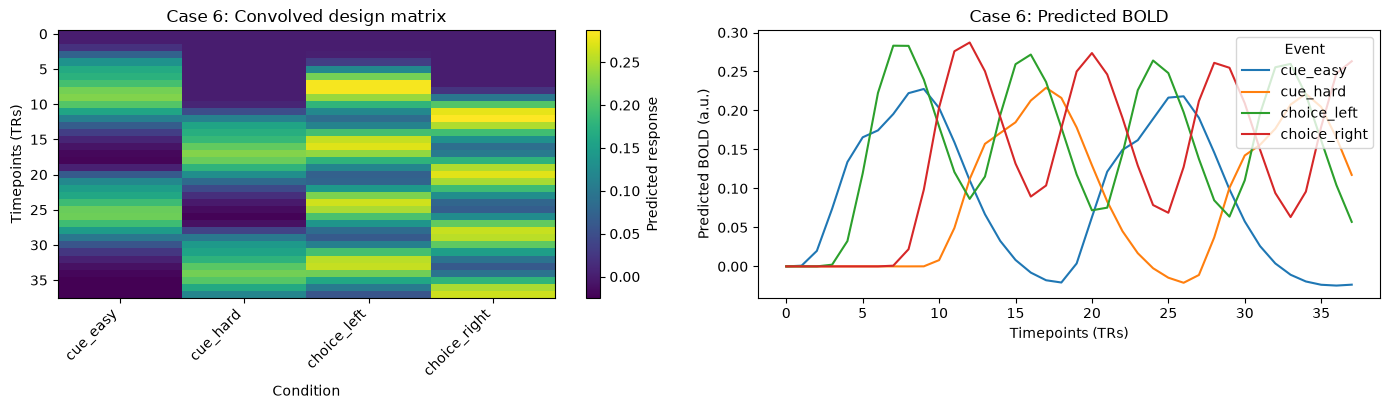

In [14]:
# Create the experiment
exp_6 = Experiment(
        TR=1.0,
        n_trials=len(order_6),
        P=[0.25, 0.25, 0.25, 0.25],
        C=np.array([
            [1, 0, 0, 0],   # cue_easy
            [0, 1, 0, 0],   # cue_hard
            [0, 0, 1, 0],   # choice_left
            [0, 0, 0, 1],   # choice_right
            [1, -1, 0, 0],  # cue_easy > cue_hard
            [0, 0, 1, -1],  # choice_left > choice_right
        ]),
        n_stimuli=4,
        rho=0.3,
        event_durations=event_durations_6,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "fixed", "value": 1.0},
        event_transition_interval={"by_event_transition": event_transition_rules_6},
        order=order_6,
        
        trial_max=max(event_durations_6),
)

# Create one concrete design
design_6 = exp_6.create_design(seed=GLOBAL_SEED + 16)
# Build the convolved design matrix
design_6.designmatrix()

# Compute the standard efficiency metrics
design_6.FeCalc()
design_6.FdCalc()
design_6.FcCalc()
design_6.FfCalc()

print(f"Fe (estimation efficiency): {design_6.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_6.Fd:.4f}")
print(f"Fc (collinearity):          {design_6.Fc:.4f}")
print(f"Ff (frequency balance):     {design_6.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_6,
    title="Case 6",
    condition_labels=labels_6,
)


---

## 7 — Variable event durations

Relative to Case 6, only one new feature is added: some event durations are now sampled rather than fixed. This is useful when the task includes self-paced or condition-specific intervals that genuinely vary across occurrences.

**Key parameters explained:**

- `event_durations` can contain a distribution specification instead of a fixed scalar.
- `trial_max` should reflect the longest possible event duration because the package needs a maximum trial length when durations vary.
- `event_durations` is still retained as a base argument even when `event_durations` is provided.
- Nothing else about the event coding has to change when durations become variable.

[{'event_index': 0,
  'gap_before': 0.6,
  'gap_type': 'initial gap',
  'label': 'cue_easy',
  'offset': 1.4,
  'onset': 0.6,
  'trial_end': 1.4,
  'trial_id': 0,
  'trial_start': 0.6},
 {'event_index': 1,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice_left',
  'offset': 3.38,
  'onset': 2.2,
  'trial_end': 3.38,
  'trial_id': 0,
  'trial_start': 2.2},
 {'event_index': 2,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue_easy',
  'offset': 5.38,
  'onset': 4.58,
  'trial_end': 5.38,
  'trial_id': 1,
  'trial_start': 4.58},
 {'event_index': 3,
  'gap_before': 0.8,
  'gap_type': 'within-trial gap',
  'label': 'choice_right',
  'offset': 7.879,
  'onset': 6.18,
  'trial_end': 7.879,
  'trial_id': 1,
  'trial_start': 6.18},
 {'event_index': 4,
  'gap_before': 1.2,
  'gap_type': 'between-trial gap',
  'label': 'cue_hard',
  'offset': 9.879,
  'onset': 9.079,
  'trial_end': 9.879,
  'trial_id': 2,
  'trial_start': 9.079},
 {'event_index': 5,
 

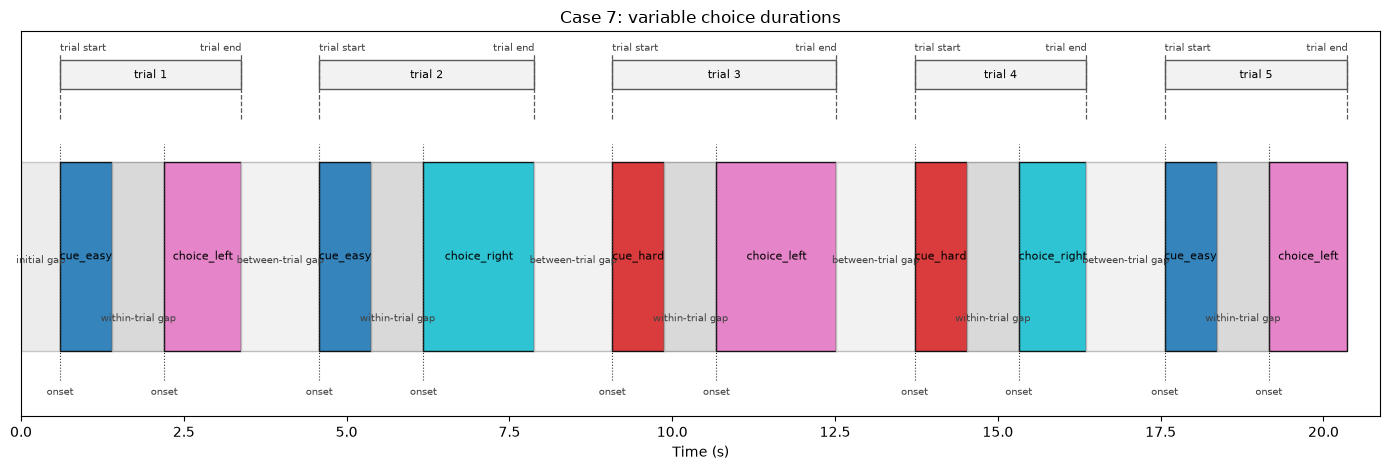

In [15]:
labels_7 = labels_6.copy()
order_7 = order_6.copy()
trial_ids_7 = trial_ids_6.copy()
event_durations_7 = [
    0.8,  # cue_easy
    0.8,  # cue_hard
    {"model": "uniform", "mean": 1.7, "min": 1.0, "max": 2.4},  # choice_left
    {"model": "uniform", "mean": 1.7, "min": 1.0, "max": 2.4},  # choice_right
]
event_transition_rules_7 = event_transition_rules_6.copy()

schedule_7, trial_bounds_7 = show_case_setup(
    title="Case 7: variable choice durations",
    order=order_7,
    labels=labels_7,
    event_durations=event_durations_7,
    event_transition_rules=event_transition_rules_7,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_7,
    max_events=10,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 835.0192
Fd (detection efficiency):  0.0658
Fc (collinearity):          0.4589
Ff (frequency balance):     1.0000


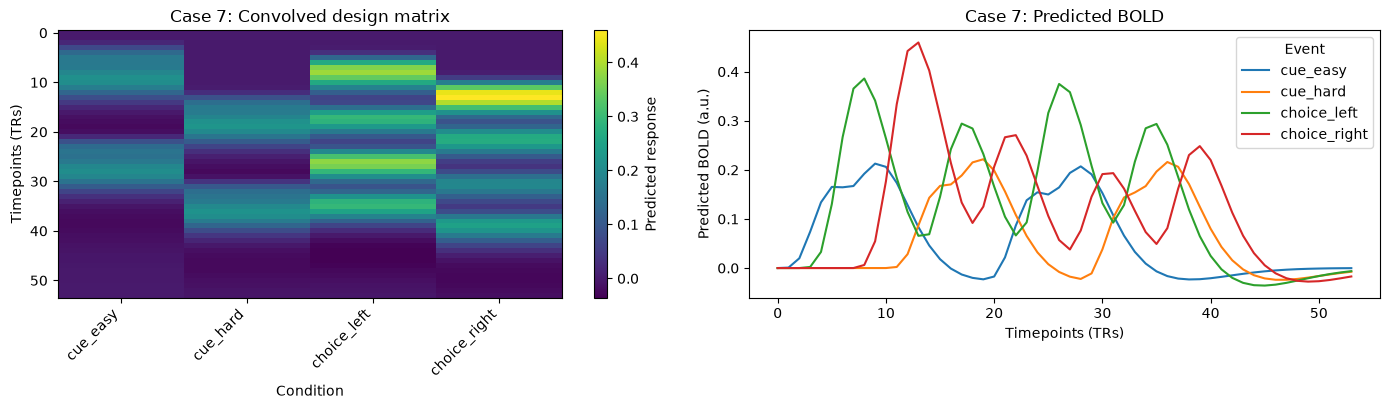

In [16]:
# Create the experiment
exp_7 = Experiment(
        TR=1.0,
        n_trials=len(order_7),
        P=[0.25, 0.25, 0.25, 0.25],
        C=np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
            [0, 0, 1, -1],
        ]),
        n_stimuli=4,
        rho=0.3,
        event_durations=event_durations_7,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "fixed", "value": 1.0},
        event_transition_interval={"by_event_transition": event_transition_rules_7},
        order=order_7,
        
        trial_max=2.4,
)

# Create one concrete design
design_7 = exp_7.create_design(seed=GLOBAL_SEED + 17)
# Build the convolved design matrix
design_7.designmatrix()

# Compute the standard efficiency metrics
design_7.FeCalc()
design_7.FdCalc()
design_7.FcCalc()
design_7.FfCalc()

print(f"Fe (estimation efficiency): {design_7.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_7.Fd:.4f}")
print(f"Fc (collinearity):          {design_7.Fc:.4f}")
print(f"Ff (frequency balance):     {design_7.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_7,
    title="Case 7",
    condition_labels=labels_7,
)


---

## 8 — Transition-specific ITIs

Relative to Case 7, only the gap logic changes. Different transitions now receive different gap distributions. This is the point at which `event_transition_interval` becomes most useful, because the same event classes can be preceded by different intervals depending on where they occur in the sequence.

**Key parameters explained:**

- `event_transition_interval` is keyed by `(previous_event, current_event)`.
- The same current event can therefore receive different gaps depending on the preceding event.
- `inter_trial_interval`, `inter_trial_interval["min"]`, `inter_trial_interval["max"]`, and `inter_trial_interval["mean"]` still need to be defined globally because the experiment container expects a scalar ITI summary.
- The timing figure should be inspected here to verify that the intended transition-specific gaps are actually present.

[{'event_index': 0,
  'gap_before': 0.503,
  'gap_type': 'initial gap',
  'label': 'cue_easy',
  'offset': 1.303,
  'onset': 0.503,
  'trial_end': 1.303,
  'trial_id': 0,
  'trial_start': 0.503},
 {'event_index': 1,
  'gap_before': 0.6,
  'gap_type': 'within-trial gap',
  'label': 'choice_left',
  'offset': 3.841,
  'onset': 1.902,
  'trial_end': 3.841,
  'trial_id': 0,
  'trial_start': 1.902},
 {'event_index': 2,
  'gap_before': 1.581,
  'gap_type': 'between-trial gap',
  'label': 'cue_easy',
  'offset': 6.222,
  'onset': 5.422,
  'trial_end': 6.222,
  'trial_id': 1,
  'trial_start': 5.422},
 {'event_index': 3,
  'gap_before': 0.317,
  'gap_type': 'within-trial gap',
  'label': 'choice_right',
  'offset': 8.257,
  'onset': 6.539,
  'trial_end': 8.257,
  'trial_id': 1,
  'trial_start': 6.539},
 {'event_index': 4,
  'gap_before': 1.218,
  'gap_type': 'between-trial gap',
  'label': 'cue_hard',
  'offset': 10.275,
  'onset': 9.475,
  'trial_end': 10.275,
  'trial_id': 2,
  'trial_start':

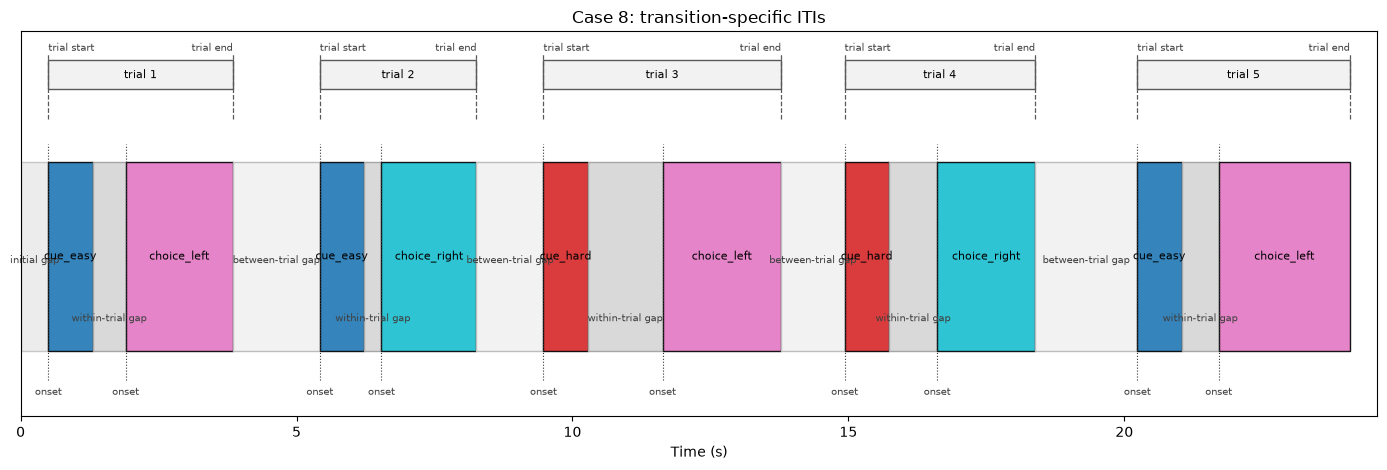

In [17]:
labels_8 = labels_7.copy()
order_8 = order_7.copy()
trial_ids_8 = trial_ids_7.copy()
event_durations_8 = event_durations_7
event_transition_rules_8 = {
    "default": {"model": "uniform", "mean": 0.8, "min": 0.4, "max": 1.2},
    (0, 2): {"model": "uniform", "mean": 0.6, "min": 0.3, "max": 0.9},
    (0, 3): {"model": "uniform", "mean": 0.6, "min": 0.3, "max": 0.9},
    (1, 2): {"model": "uniform", "mean": 1.1, "min": 0.8, "max": 1.4},
    (1, 3): {"model": "uniform", "mean": 1.1, "min": 0.8, "max": 1.4},
    (2, 0): {"model": "uniform", "mean": 1.5, "min": 1.1, "max": 1.9},
    (2, 1): {"model": "uniform", "mean": 1.5, "min": 1.1, "max": 1.9},
    (3, 0): {"model": "uniform", "mean": 1.5, "min": 1.1, "max": 1.9},
    (3, 1): {"model": "uniform", "mean": 1.5, "min": 1.1, "max": 1.9},
}

schedule_8, trial_bounds_8 = show_case_setup(
    title="Case 8: transition-specific ITIs",
    order=order_8,
    labels=labels_8,
    event_durations=event_durations_8,
    event_transition_rules=event_transition_rules_8,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_8,
    max_events=10,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 404.7247
Fd (detection efficiency):  0.0812
Fc (collinearity):          0.4589
Ff (frequency balance):     1.0000


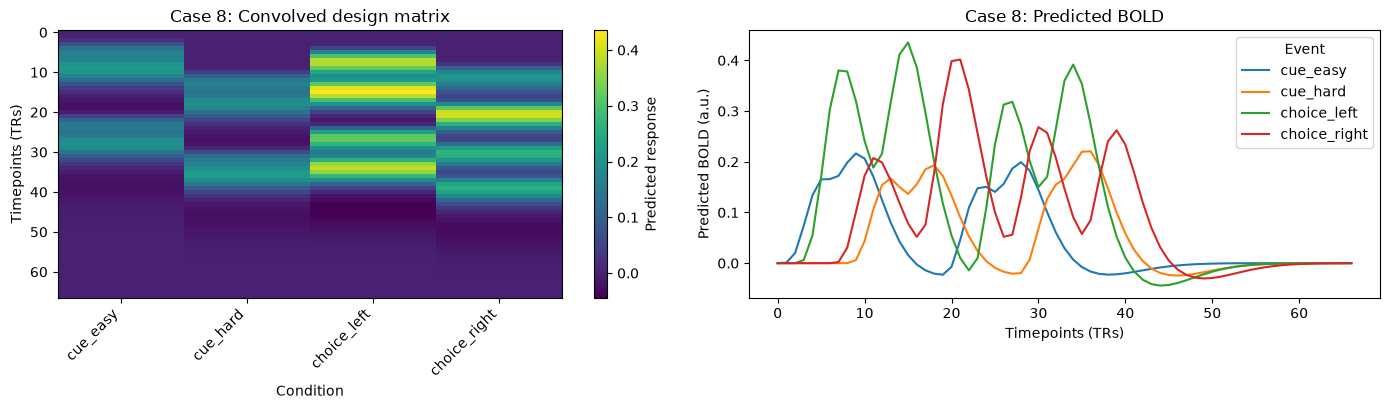

In [18]:
# Create the experiment
exp_8 = Experiment(
        TR=1.0,
        n_trials=len(order_8),
        P=[0.25, 0.25, 0.25, 0.25],
        C=np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
            [0, 0, 1, -1],
        ]),
        n_stimuli=4,
        rho=0.3,
        event_durations=event_durations_8,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "uniform", "min": 0.3, "max": 1.9, "mean": 1.1},
        event_transition_interval={"by_event_transition": event_transition_rules_8},
        order=order_8,
        
        trial_max=2.4,
)

# Create one concrete design
design_8 = exp_8.create_design(seed=GLOBAL_SEED + 18)
# Build the convolved design matrix
design_8.designmatrix()

# Compute the standard efficiency metrics
design_8.FeCalc()
design_8.FdCalc()
design_8.FcCalc()
design_8.FfCalc()

print(f"Fe (estimation efficiency): {design_8.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_8.Fd:.4f}")
print(f"Fc (collinearity):          {design_8.Fc:.4f}")
print(f"Ff (frequency balance):     {design_8.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_8,
    title="Case 8",
    condition_labels=labels_8,
)


---

## 9 — Branching trial templates sampled as sequence units

Relative to Case 8, only one new element is added: trial templates are now sampled as units and then flattened into the event-level order. This is the cleanest way to represent branching trial types such as a standard trial versus a trial that inserts an extra hint screen.

**Key parameters explained:**

- `order_keys` defines the event sequence for each conceptual trial template.
- `order_probabilities` defines how often each template is sampled.
- `order_length` is the requested length of the final event-level order after the sampled templates are flattened.
- The package still needs the flattened `order` internally, so the tutorial shows the trial list and its expansion explicitly.

Sampled conceptual trial list: [0, 0, 1, 0, 0, 1, 0, 0]
Expanded event-level order: [0, 2, 5, 0, 2, 5, 1, 4, 3, 5, 0, 2, 5, 0, 2, 5, 1, 4, 3, 5, 0, 2, 5, 0, 2, 5]
[{'event_index': 0,
  'gap_before': 0.39,
  'gap_type': 'initial gap',
  'label': 'cue_easy',
  'offset': 1.19,
  'onset': 0.39,
  'trial_end': 1.19,
  'trial_id': 0,
  'trial_start': 0.39},
 {'event_index': 1,
  'gap_before': 0.7,
  'gap_type': 'within-trial gap',
  'label': 'choice_left',
  'offset': 3.19,
  'onset': 1.89,
  'trial_end': 3.19,
  'trial_id': 0,
  'trial_start': 1.89},
 {'event_index': 2,
  'gap_before': 0.441,
  'gap_type': 'within-trial gap',
  'label': 'feedback',
  'offset': 4.63,
  'onset': 3.63,
  'trial_end': 4.63,
  'trial_id': 0,
  'trial_start': 3.63},
 {'event_index': 3,
  'gap_before': 1.023,
  'gap_type': 'between-trial gap',
  'label': 'cue_easy',
  'offset': 6.453,
  'onset': 5.653,
  'trial_end': 6.453,
  'trial_id': 1,
  'trial_start': 5.653},
 {'event_index': 4,
  'gap_before': 0.489,
  'gap

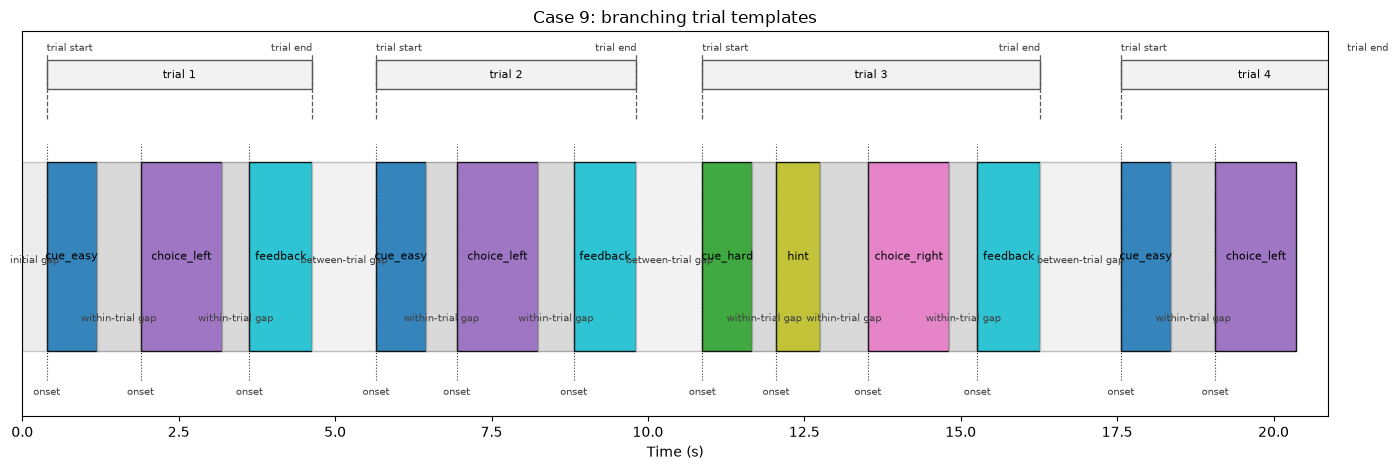

In [19]:
labels_9 = {
    0: "cue_easy",
    1: "cue_hard",
    2: "choice_left",
    3: "choice_right",
    4: "hint",
    5: "feedback",
}
keys_9 = [
    [0, 2, 5],      # standard trial: cue_easy -> choice_left -> feedback
    [1, 4, 3, 5],   # branch trial: cue_hard -> hint -> choice_right -> feedback
]
trial_probabilities_9 = [0.6, 0.4]

rng_9 = np.random.default_rng(GLOBAL_SEED)
trial_list_9 = rng_9.choice(len(keys_9), size=8, p=trial_probabilities_9).tolist()
order_9 = tlist_to_order(trial_list_9, keys_9)
trial_ids_9 = trial_list_to_ids(trial_list_9, keys_9)

print("Sampled conceptual trial list:", trial_list_9)
print("Expanded event-level order:", order_9)

event_durations_9 = [0.8, 0.8, 1.3, 1.3, 0.7, 1.0]
event_transition_rules_9 = {
    "default": {"model": "uniform", "mean": 0.65, "min": 0.3, "max": 1.0},
    (0, 2): {"model": "uniform", "mean": 0.7, "min": 0.4, "max": 1.0},
    (1, 4): {"model": "uniform", "mean": 0.6, "min": 0.3, "max": 0.9},
    (4, 3): {"model": "uniform", "mean": 0.5, "min": 0.2, "max": 0.8},
    (2, 5): {"model": "uniform", "mean": 0.4, "min": 0.2, "max": 0.6},
    (3, 5): {"model": "uniform", "mean": 0.4, "min": 0.2, "max": 0.6},
    (5, 0): {"model": "uniform", "mean": 1.4, "min": 1.0, "max": 1.8},
    (5, 1): {"model": "uniform", "mean": 1.4, "min": 1.0, "max": 1.8},
}

schedule_9, trial_bounds_9 = show_case_setup(
    title="Case 9: branching trial templates",
    order=order_9,
    labels=labels_9,
    event_durations=event_durations_9,
    event_transition_rules=event_transition_rules_9,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_9,
    max_events=12,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 480.6182
Fd (detection efficiency):  0.0138
Fc (collinearity):          0.2925
Ff (frequency balance):     0.8205


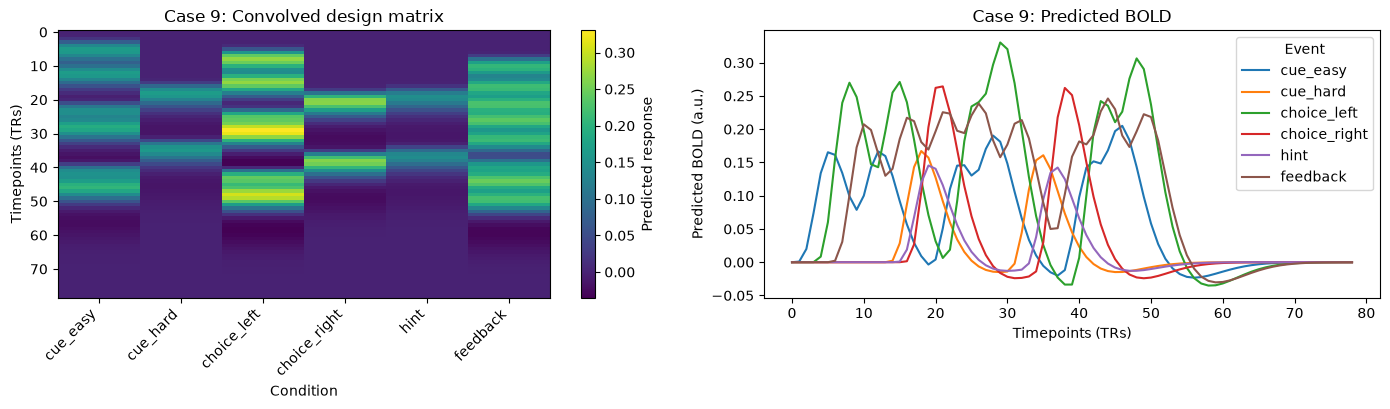

In [20]:
# Create the experiment
exp_9 = Experiment(
        TR=1.0,
        n_trials=len(order_9),
        P=[0.15, 0.10, 0.15, 0.10, 0.10, 0.40],
        C=np.array([
            [1, 0, 0, 0, 0, 0],   # cue_easy
            [0, 1, 0, 0, 0, 0],   # cue_hard
            [0, 0, 1, 0, 0, 0],   # choice_left
            [0, 0, 0, 1, 0, 0],   # choice_right
            [0, 0, 0, 0, 1, 0],   # hint
            [0, 0, 0, 0, 0, 1],   # feedback
            [0, 0, 1, -1, 0, 0],  # choice_left > choice_right
        ]),
        n_stimuli=6,
        rho=0.3,
        event_durations=event_durations_9,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "uniform", "min": 0.2, "max": 1.8, "mean": 1.0},
        event_transition_interval={"by_event_transition": event_transition_rules_9},
        order=order_9,
        
        trial_max=max(event_durations_9),
        # Conceptual-template version inside neurodesign-plus:
        # order_keys=keys_9,
        # order_probabilities=trial_probabilities_9,
        # order_length=8,
)

# Create one concrete design
design_9 = exp_9.create_design(seed=GLOBAL_SEED + 19)
# Build the convolved design matrix
design_9.designmatrix()

# Compute the standard efficiency metrics
design_9.FeCalc()
design_9.FdCalc()
design_9.FcCalc()
design_9.FfCalc()

print(f"Fe (estimation efficiency): {design_9.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_9.Fd:.4f}")
print(f"Fc (collinearity):          {design_9.Fc:.4f}")
print(f"Ff (frequency balance):     {design_9.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_9,
    title="Case 9",
    condition_labels=labels_9,
)


---

## 10 — A combined design with alternating trial families

This final case combines the features introduced above: multiple event classes, variable durations, transition-specific ITIs, and three conceptual trial templates. It is still a generic decision-making task, but the representation now resembles the complexity of a real fMRI design notebook.

**Key parameters explained:**

- The conceptual trial families are defined as templates and then expanded into the event-level `order`.
- `P` is specified at the event-class level, not at the conceptual-template level.
- `trial_max` is set by the longest possible event duration across all classes.
- When the design becomes this rich, the timing figure and the convolved design matrix should always be inspected together.

Sampled conceptual trial list: [0, 2, 0, 0, 0, 0, 1, 0, 2, 2]
Expanded event-level order: [0, 2, 6, 0, 5, 2, 6, 0, 2, 6, 0, 2, 6, 0, 2, 6, 0, 2, 6, 1, 4, 3, 6, 0, 2, 6, 0, 5, 2, 6, 0, 5, 2, 6]
[{'event_index': 0,
  'gap_before': 0.39,
  'gap_type': 'initial gap',
  'label': 'cue_easy',
  'offset': 1.19,
  'onset': 0.39,
  'trial_end': 1.19,
  'trial_id': 0,
  'trial_start': 0.39},
 {'event_index': 1,
  'gap_before': 0.649,
  'gap_type': 'within-trial gap',
  'label': 'choice_left',
  'offset': 3.355,
  'onset': 1.839,
  'trial_end': 3.355,
  'trial_id': 0,
  'trial_start': 1.839},
 {'event_index': 2,
  'gap_before': 0.501,
  'gap_type': 'within-trial gap',
  'label': 'feedback',
  'offset': 4.856,
  'onset': 3.856,
  'trial_end': 4.856,
  'trial_id': 0,
  'trial_start': 3.856},
 {'event_index': 3,
  'gap_before': 1.026,
  'gap_type': 'between-trial gap',
  'label': 'cue_easy',
  'offset': 6.682,
  'onset': 5.882,
  'trial_end': 6.682,
  'trial_id': 1,
  'trial_start': 5.882},
 {'event_

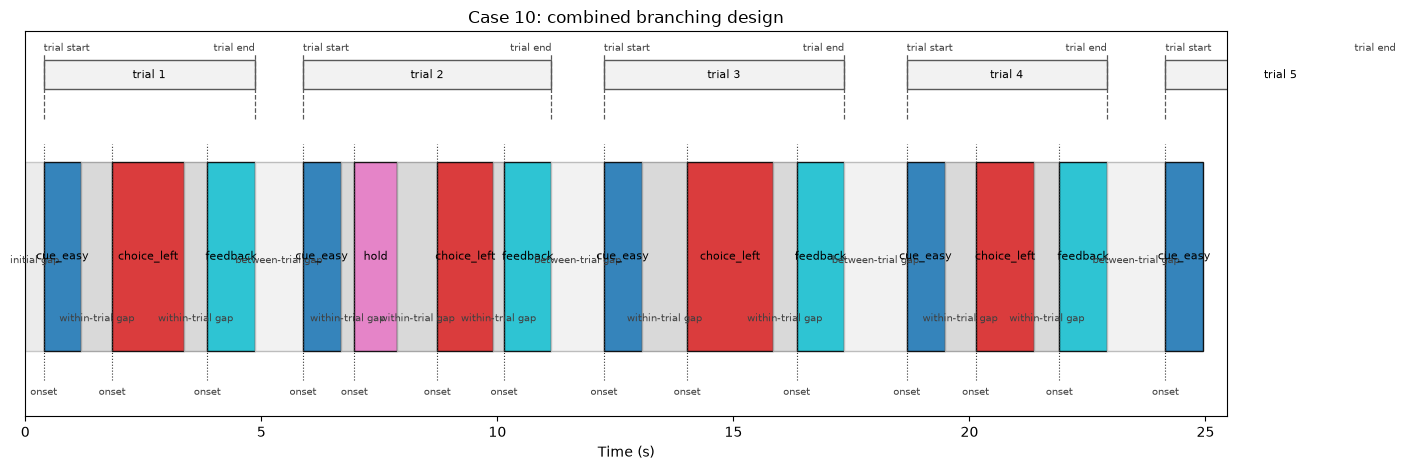

In [21]:
labels_10 = {
    0: "cue_easy",
    1: "cue_hard",
    2: "choice_left",
    3: "choice_right",
    4: "hint",
    5: "hold",
    6: "feedback",
}
keys_10 = [
    [0, 2, 6],         # standard
    [1, 4, 3, 6],      # hint branch
    [0, 5, 2, 6],      # hold branch
]
trial_probabilities_10 = [0.4, 0.35, 0.25]

rng_10 = np.random.default_rng(GLOBAL_SEED + 1)
trial_list_10 = rng_10.choice(len(keys_10), size=10, p=trial_probabilities_10).tolist()
order_10 = tlist_to_order(trial_list_10, keys_10)
trial_ids_10 = trial_list_to_ids(trial_list_10, keys_10)

print("Sampled conceptual trial list:", trial_list_10)
print("Expanded event-level order:", order_10)

event_durations_10 = [
    0.8,                                                   # cue_easy
    0.8,                                                   # cue_hard
    {"model": "uniform", "mean": 1.6, "min": 1.0, "max": 2.2},  # choice_left
    {"model": "uniform", "mean": 1.6, "min": 1.0, "max": 2.2},  # choice_right
    0.7,                                                   # hint
    0.9,                                                   # hold
    1.0,                                                   # feedback
]
event_transition_rules_10 = {
    "default": {"model": "uniform", "mean": 0.65, "min": 0.3, "max": 1.0},
    (0, 2): {"model": "uniform", "mean": 0.65, "min": 0.3, "max": 1.0},
    (1, 4): {"model": "uniform", "mean": 0.6, "min": 0.3, "max": 0.9},
    (4, 3): {"model": "uniform", "mean": 0.5, "min": 0.2, "max": 0.8},
    (0, 5): {"model": "uniform", "mean": 0.5, "min": 0.2, "max": 0.8},
    (5, 2): {"model": "uniform", "mean": 0.6, "min": 0.3, "max": 0.9},
    (2, 6): {"model": "uniform", "mean": 0.45, "min": 0.2, "max": 0.7},
    (3, 6): {"model": "uniform", "mean": 0.45, "min": 0.2, "max": 0.7},
    (6, 0): {"model": "uniform", "mean": 1.45, "min": 1.0, "max": 1.9},
    (6, 1): {"model": "uniform", "mean": 1.45, "min": 1.0, "max": 1.9},
}

schedule_10, trial_bounds_10 = show_case_setup(
    title="Case 10: combined branching design",
    order=order_10,
    labels=labels_10,
    event_durations=event_durations_10,
    event_transition_rules=event_transition_rules_10,
    trial_start_interval=0.0,
    post_event_interval=0.0,
    trial_ids=trial_ids_10,
    max_events=14,
)

c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1031: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Fe (estimation efficiency): 0.5702
Fd (detection efficiency):  0.0149
Fc (collinearity):          0.2825
Ff (frequency balance):     0.7072


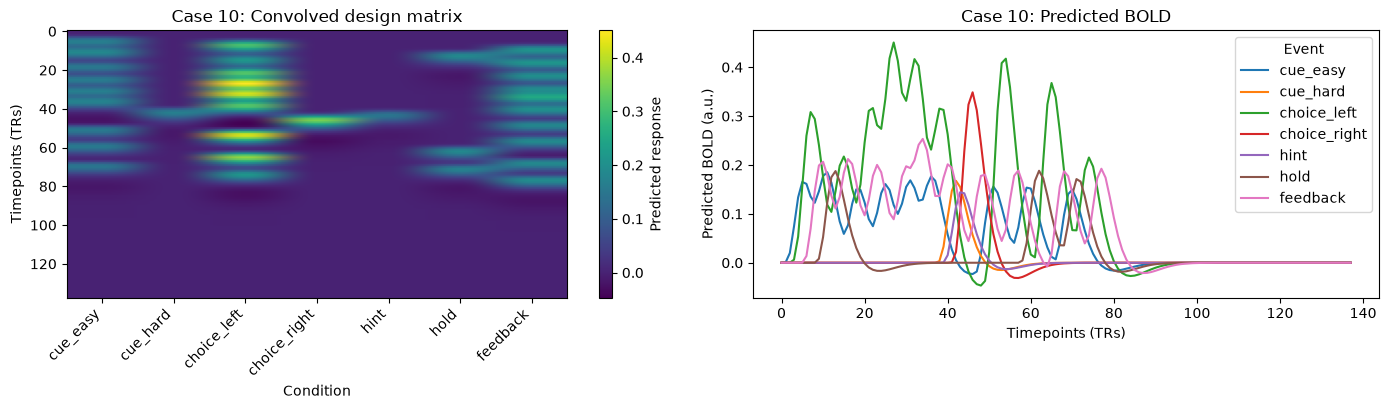

In [22]:
# Create the experiment
exp_10 = Experiment(
        TR=1.0,
        n_trials=len(order_10),
        P=[0.18, 0.12, 0.16, 0.12, 0.10, 0.10, 0.22],
        C=np.array([
            [1, 0, 0, 0, 0, 0, 0],   # cue_easy
            [0, 1, 0, 0, 0, 0, 0],   # cue_hard
            [0, 0, 1, 0, 0, 0, 0],   # choice_left
            [0, 0, 0, 1, 0, 0, 0],   # choice_right
            [0, 0, 0, 0, 1, 0, 0],   # hint
            [0, 0, 0, 0, 0, 1, 0],   # hold
            [0, 0, 0, 0, 0, 0, 1],   # feedback
            [0, 0, 1, -1, 0, 0, 0],  # choice_left > choice_right
            [1, -1, 0, 0, 0, 0, 0],  # cue_easy > cue_hard
        ]),
        n_stimuli=7,
        rho=0.3,
        event_durations=event_durations_10,
        trial_start_interval=0.0,
        post_event_interval=0.0,
        inter_trial_interval={"model": "uniform", "min": 0.2, "max": 1.9, "mean": 1.05},
        event_transition_interval={"by_event_transition": event_transition_rules_10},
        order=order_10,
        
        trial_max=2.2,
        # Conceptual-template version inside neurodesign-plus:
        # order_keys=keys_10,
        # order_probabilities=trial_probabilities_10,
        # order_length=10,
)

# Create one concrete design
design_10 = exp_10.create_design(seed=GLOBAL_SEED + 20)
# Build the convolved design matrix
design_10.designmatrix()

# Compute the standard efficiency metrics
design_10.FeCalc()
design_10.FdCalc()
design_10.FcCalc()
design_10.FfCalc()

print(f"Fe (estimation efficiency): {design_10.Fe:.4f}")
print(f"Fd (detection efficiency):  {design_10.Fd:.4f}")
print(f"Fc (collinearity):          {design_10.Fc:.4f}")
print(f"Ff (frequency balance):     {design_10.Ff:.4f}")

# Show what this design produces
show_design_outputs(
    design_10,
    title="Case 10",
    condition_labels=labels_10,
)


---

## 11 — Common points of confusion

1. **Why does `n_trials` look too large once the design becomes complex?**  
   Because it counts event-level entries. If one conceptual trial contains `cue -> choice -> feedback`, that one trial contributes three entries to `order`.

2. **Why does a design with one cue and two choice conditions need three codes rather than two?**  
   Because the design matrix needs separate regressors for `cue`, `choice_left`, and `choice_right`. Conceptual phases and modeled regressors are not the same object.

3. **Why does the package still want a global ITI specification when I already gave `event_transition_interval`?**  
   Because the experiment container still expects a scalar ITI summary. The conditional ITI dictionary refines the concrete event schedule, but it does not remove the need for a global ITI model.

4. **When should I use `trial_start_interval` rather than a second event?**  
   Use `trial_start_interval` when the interval before the event is not itself a regressor of interest. If that interval has its own condition structure or should be estimated separately, it should usually become its own event class.

5. **Why does the first-cell figure show both within-trial gaps and between-trial gaps?**  
   Because the notebook becomes event-level once a conceptual trial contains more than one modeled event. The gap before an event can therefore fall either inside the current conceptual trial or between two conceptual trials.

6. **When should I use `order_keys` rather than building `order` directly?**  
   Use `order_keys` when conceptual trial templates must remain intact during sampling. The current implementation flattens the sampled templates and then truncates the result to `order_length`, so it is best suited to motif-based sampling rather than to guaranteeing a complete template decomposition of the full run. Use a direct `order` when the full event sequence is already known.


## 12 — Where to go next

The next natural step is optimization rather than manual construction. Once the event coding is correct, the same representational logic can be passed to `Optimisation` to search over orders and ITIs. The important point is that optimization only becomes meaningful after the event-level representation is correct. The examples above are therefore not just toy designs. They are the scaffolding needed to specify real designs without ambiguity.